In [84]:
import pandas as pd 
import scipy.stats as stats
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm, cauchy
import numpy as np

In [85]:
'''data gathered over one day (84600 secs)
divide the counts value by #seconds and then divide by the bin width (#/s/kev)'''
df = pd.read_parquet('/Users/laurencadle/Downloads/singlesites.parquet')
df.head(10)


,Event ID,Detector ID,p/n,Strip ID,ADC,Energy,Energy Resolution
0,1,10,l,25,632.072547,142.916205,0.890518
1,1,10,l,26,416.967557,97.124066,0.932265
2,1,10,h,19,1032.747190,260.427088,0.621150
3,3,10,l,31,163.898870,32.180491,1.007946
4,3,10,l,32,496.765587,107.659359,0.914745
5,3,10,h,13,458.300481,136.185105,1.100058
6,6,10,l,24,269.199516,60.456429,0.839650
7,6,10,h,3,266.536530,57.026391,0.962091
8,7,10,l,6,528.392208,109.370414,1.084959
9,7,10,h,31,479.690910,109.409398,0.997809


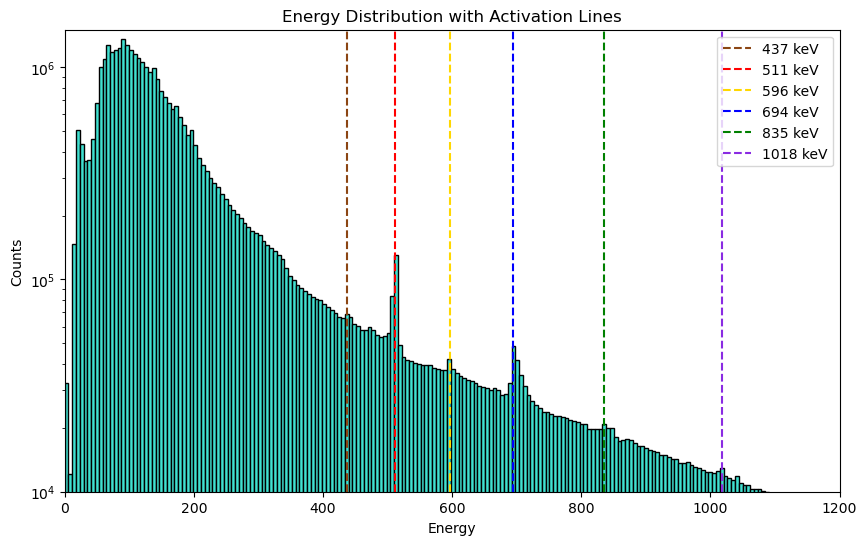

In [ ]:
#energy distribution and activation lines
'''looking for activation lines and peaks. next step: plot out peaks and fit a couple of different curves, try to fit something to the 511kev line,
gaussian on 511 and 694 - try hyperbolic'''

plt.figure(figsize=(10, 6))
plt.hist(df['Energy'], bins=500, color = 'turquoise', edgecolor = 'black')
plt.title('Energy Distribution with Activation Lines')
plt.xlabel('Energy')
plt.ylabel('Counts')

x1 = 437
x2 = 511
x3 = 596
x4 = 694
x5 = 835
x6 = 1018

plt.axvline(x=x1, color='saddlebrown', linestyle='--', label=f'{x1} keV')
plt.axvline(x=x2, color='red', linestyle='--', label=f'{x2} keV')
plt.axvline(x=x3, color='gold', linestyle='--', label=f'{x3} keV')
plt.axvline(x=x4, color='blue', linestyle='--', label=f'{x4} keV')
plt.axvline(x=x5, color='green', linestyle='--', label=f'{x5} keV')
plt.axvline(x=x6, color='blueviolet', linestyle='--', label=f'{x6} keV')

plt.xlim(0, 1200)
plt.ylim(1e4, 1500000)
plt.yscale('log')
plt.legend()
plt.show()
#UPDATE LINES!!! use f strings

code review for 511/964 keV plots:
i did a lot of playing with the scaling for these - i tried using the +c recommendation, but i found that the cx+d worked a little better for a tighter fit. i implemented this change for the gaussian/lorentzian/hyperbolic fits, but the fits for the 694 look much better than those done for the 511. i'm curious about how i can further improve this. i also played around with the scalings for the peak_mask because that impacted whether or not the tails were visible (they became less visible as i made this range more narrow). i am more proud of the 694 plot than i am the 511, which was more disappointing because i can't figure out how to make it better. from last time, however, i think i made good change and implemented the changes i needed to. also, i need to take better notes on what i need to do because i often find myself getting lost or frustrated with my task to do because my notes aren't good. that's definitely something i can improve on!

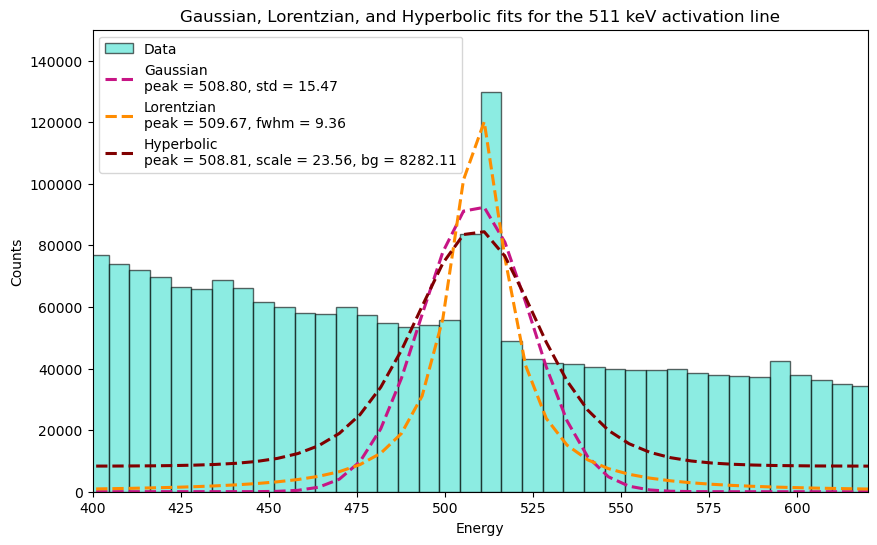

In [ ]:
#fits for 511 keV line BEFORE 4/16 edits
#gaussian
mask = (df['Energy'] > 480) & (df['Energy'] < 540)
dist = df['Energy'][mask].to_numpy()

mu, sigma = norm.fit(dist)

counts, bin_edges = np.histogram(df['Energy'], bins=500)
bin_width = bin_edges[1] - bin_edges[0]

x = np.linspace(bin_edges[0], bin_edges[-1], 500)
pdf_gaussian = norm.pdf(x, mu, sigma)
pdf_gaussian_scaled = pdf_gaussian * (len(dist) * bin_width)

#lorentzian
mu_l, gamma = cauchy.fit(dist)
pdf_lorentzian = cauchy.pdf(x, mu_l, gamma)
pdf_lorentzian_scaled = pdf_lorentzian * (len(dist) * bin_width)

#hyperbolic
'''put another variable (+c) to have the peaks appear over a flat background - a power law peak would be on top of the flat slope
to add more complex shapes add more (+cx+d for example)'''

def hyperbolic_pdf(x, mu, scale):
    return (1 / (2 * scale)) * (1 / np.cosh((x - mu) / scale)) ** 2

def hyperbolic_scaled(x, mu, scale, c):
    return hyperbolic_pdf(x, mu, scale) * (len(dist) * bin_width) +c

p0 = [511, 5, 0]
#popt, _ = curve_fit(hyperbolic_scaled, x, hyperbolic_scaled(x, *[511, 5]), p0=p0)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
peak_mask = (bin_centers > 480) & (bin_centers < 540)
popt, _ = curve_fit(hyperbolic_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0)
pdf_hyperbolic_scaled = hyperbolic_scaled(x, *popt)

plt.figure(figsize=(10, 6))
plt.hist(df['Energy'], bins=500, color='turquoise', edgecolor='black', label='Data', alpha=0.6)
plt.title('Gaussian, Lorentzian, and Hyperbolic fits for the 511 keV activation line')
plt.plot(x, pdf_gaussian_scaled, linewidth=2.2, linestyle='--', color='mediumvioletred', label=f'Gaussian\npeak = {mu:.2f}, std = {sigma:.2f}')
plt.plot(x, pdf_lorentzian_scaled, linewidth=2.2, linestyle='--', color='darkorange', label=f'Lorentzian\npeak = {mu_l:.2f}, fwhm = {gamma:.2f}')
plt.plot(x, pdf_hyperbolic_scaled, linewidth=2.2, linestyle='--', color='maroon', label=f'Hyperbolic\npeak = {popt[0]:.2f}, scale = {popt[1]:.2f}, bg = {popt[2]:.2f}')
plt.xlabel('Energy')
plt.ylabel('Counts')
plt.xlim(400, 620)
plt.ylim(0, 150000)
plt.legend()
plt.show()

/var/folders/fg/vj5g3cns681b1nwf65lgp4g40000gn/T/ipykernel_971/1696340627.py:33: RuntimeWarning: overflow encountered in cosh
  return (1 / (2 * scale)) * (1 / np.cosh((x - mu) / scale)) ** 2


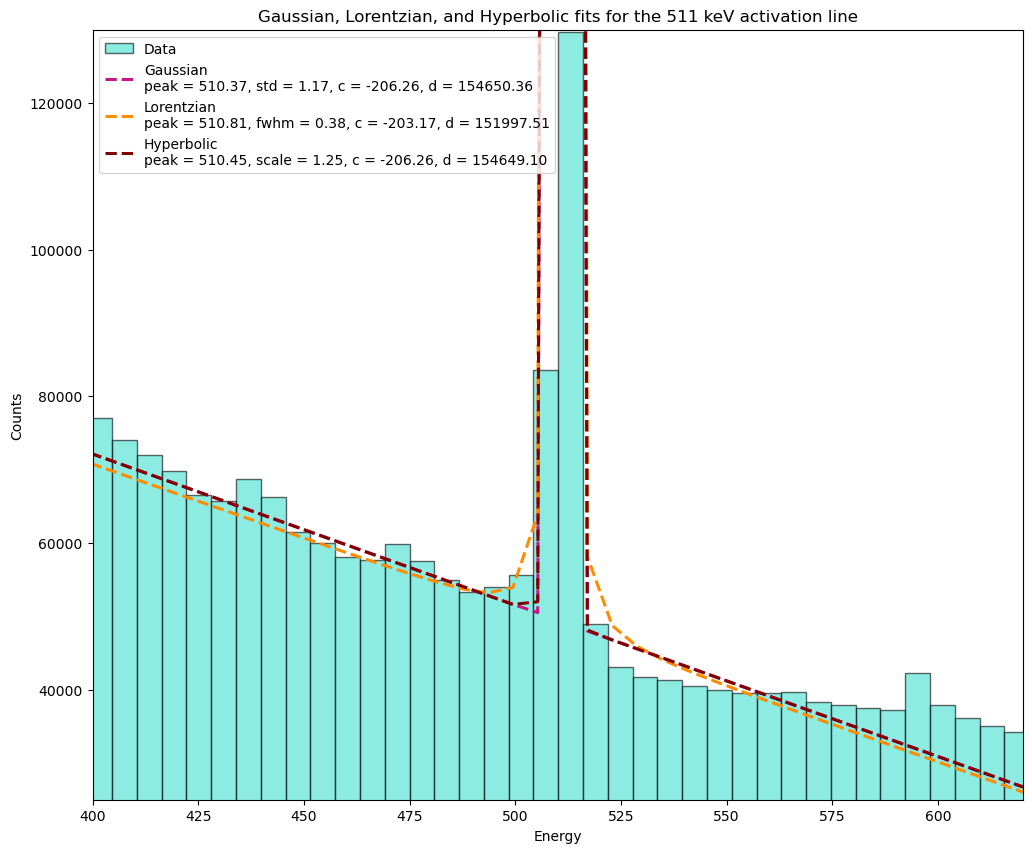

In [99]:
#fits for 511 keV line AFTER 4/16 edits
#slope: 50000 - 60000 / 580 - 450 = -77
mask = (df['Energy'] > 480) & (df['Energy'] < 540)
dist = df['Energy'][mask].to_numpy()

N=500
counts, bin_edges = np.histogram(df['Energy'], bins=N)
bin_width = bin_edges[1] - bin_edges[0]

x = np.linspace(bin_edges[0], bin_edges[-1], N)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
peak_mask = (bin_centers > 450) & (bin_centers < 580)

#gaussian
def gaussian_scaled(x, mu, sigma, c, d):
    return norm.pdf(x, mu, sigma) * (len(dist) * bin_width) + c * x + d

p0_gauss = [511, 2, -77, counts[peak_mask].min()]
popt_g, _ = curve_fit(gaussian_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0_gauss)
pdf_gaussian_scaled = gaussian_scaled(x, *popt_g)

#lorentzian
def lorentzian_scaled(x, mu, gamma, c, d):
    return cauchy.pdf(x, mu, gamma) * (len(dist) * bin_width) + c * x + d

p0_lor = [511, 2, -77, counts[peak_mask].min()]
popt_l, _ = curve_fit(lorentzian_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0_lor)
pdf_lorentzian_scaled = lorentzian_scaled(x, *popt_l)

#hyperbolic
def hyperbolic_pdf(x, mu, scale):
    return (1 / (2 * scale)) * (1 / np.cosh((x - mu) / scale)) ** 2

def hyperbolic_scaled(x, mu, scale, c, d):
    return hyperbolic_pdf(x, mu, scale) * (len(dist) * bin_width) + c * x + d

p0 = [511, 2, -77, counts[peak_mask].min()]
popt, _ = curve_fit(hyperbolic_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0)
pdf_hyperbolic_scaled = hyperbolic_scaled(x, *popt)

plt.figure(figsize=(12, 10))
plt.hist(df['Energy'], bins=N, color='turquoise', edgecolor='black', label='Data', alpha=0.6)
plt.title('Gaussian, Lorentzian, and Hyperbolic fits for the 511 keV activation line')
plt.plot(x, pdf_gaussian_scaled, linewidth=2.2, linestyle='--', color='mediumvioletred', label=f'Gaussian\npeak = {popt_g[0]:.2f}, std = {popt_g[1]:.2f}, c = {popt_g[2]:.2f}, d = {popt_g[3]:.2f}')
plt.plot(x, pdf_lorentzian_scaled, linewidth=2.2, linestyle='--', color='darkorange', label=f'Lorentzian\npeak = {popt_l[0]:.2f}, fwhm = {popt_l[1]:.2f}, c = {popt_l[2]:.2f}, d = {popt_l[3]:.2f}')
plt.plot(x, pdf_hyperbolic_scaled, linewidth=2.2, linestyle='--', color='maroon', label=f'Hyperbolic\npeak = {popt[0]:.2f}, scale = {popt[1]:.2f}, c = {popt[2]:.2f}, d = {popt[3]:.2f}')
plt.xlabel('Energy')
plt.ylabel('Counts')
plt.xlim(400, 620)
plt.ylim(25000, 130000)
plt.legend()
plt.show()

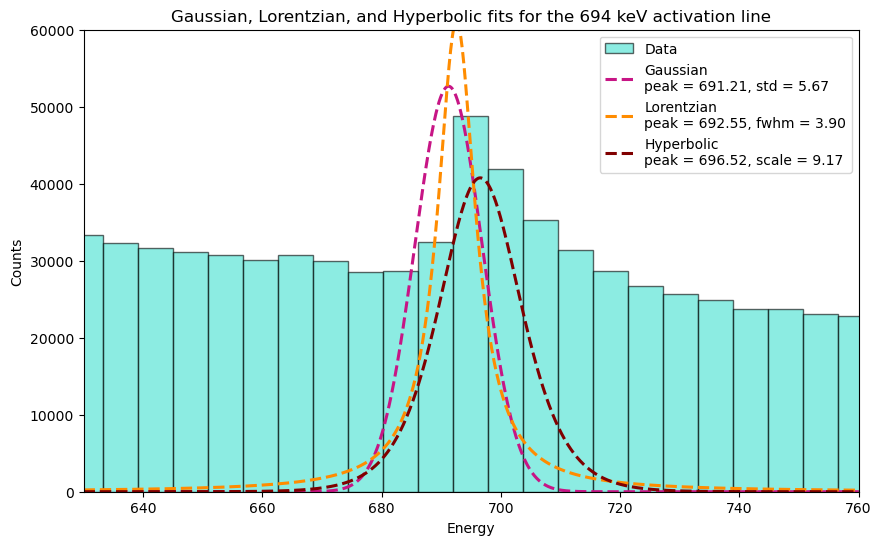

In [ ]:
#fits for the 694 keV line BEFORE 4/16 edits
#gaussian
mask = (df['Energy'] > 680) & (df['Energy'] < 700)
dist = df['Energy'][mask].to_numpy()

mu, sigma = norm.fit(dist)

counts, bin_edges = np.histogram(df['Energy'], bins=500)
bin_width = bin_edges[1] - bin_edges[0]

x1 = np.linspace(630, 760, 1000)
#x = np.linspace(bin_edges[0], bin_edges[-1], 500)
pdf_gaussian = norm.pdf(x1, mu, sigma)
pdf_gaussian_scaled = pdf_gaussian * (len(dist) * bin_width)

#lorentzian
mu_l, gamma = cauchy.fit(dist)
pdf_lorentzian = cauchy.pdf(x1, mu_l, gamma)
pdf_lorentzian_scaled = pdf_lorentzian * (len(dist) * bin_width)

#hyperbolic
def hyperbolic_pdf(x1, mu, scale):
    return (1 / (2 * scale)) * (1 / np.cosh((x1 - mu) / scale)) ** 2

def hyperbolic_scaled(x1, mu, scale):
    return hyperbolic_pdf(x1, mu, scale) * (len(dist) * bin_width)

p0 = [694, 5]
popt, _ = curve_fit(hyperbolic_scaled, x1, hyperbolic_scaled(x1, *[694, 5]), p0=p0)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
peak_mask = (bin_centers > 680) & (bin_centers < 710)
popt, _ = curve_fit(hyperbolic_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0)
'''let x1 = np.linspace(630, 760, 1000) and replace x wiht x1'''
pdf_hyperbolic_scaled = hyperbolic_scaled(x1, *popt)

plt.figure(figsize=(10, 6))
plt.hist(df['Energy'], bins=500, color='turquoise', edgecolor='black', label='Data', alpha=0.6)
plt.title('Gaussian, Lorentzian, and Hyperbolic fits for the 694 keV activation line')
'''define a new variable x1 that uses a different sampling that has more datapoints - x1 = np.linspace(630, 760, 1000)'''
plt.plot(x1, pdf_gaussian_scaled, linewidth=2.2, linestyle='--', color='mediumvioletred', label=f'Gaussian\npeak = {mu:.2f}, std = {sigma:.2f}')
plt.plot(x1, pdf_lorentzian_scaled, linewidth=2.2, linestyle='--', color='darkorange', label=f'Lorentzian\npeak = {mu_l:.2f}, fwhm = {gamma:.2f}')
plt.plot(x1, pdf_hyperbolic_scaled, linewidth=2.2, linestyle='--', color='maroon', label=f'Hyperbolic\npeak = {popt[0]:.2f}, scale = {popt[1]:.2f}')
plt.xlabel('Energy')
plt.ylabel('Counts')
plt.xlim(630, 760)
plt.ylim(0, 60000)
plt.legend()
plt.show()

/var/folders/fg/vj5g3cns681b1nwf65lgp4g40000gn/T/ipykernel_971/1357860301.py:39: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(hyperbolic_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0)


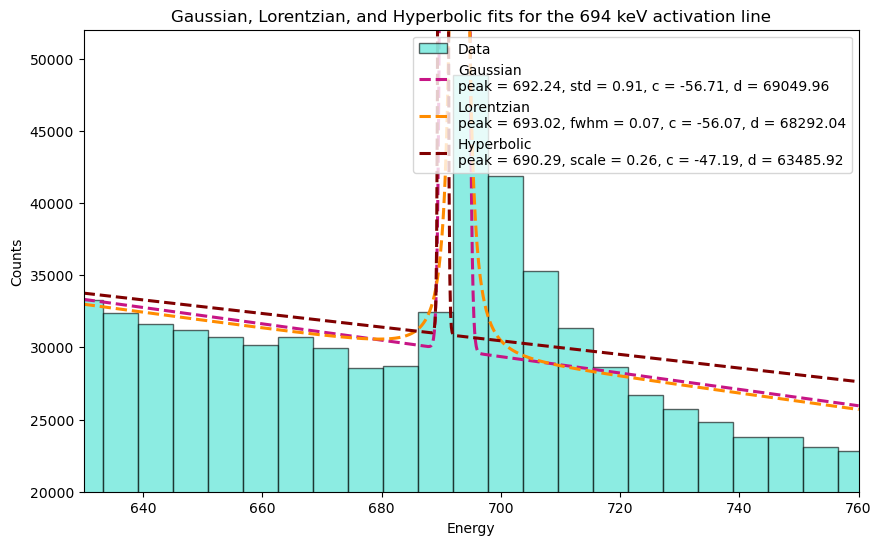

In [127]:
#fits for the 694 keV line AFTER 4/16 edits
#slope: 33000 - 30000 / 690 - 720 = -75
mask = (df['Energy'] > 650) & (df['Energy'] < 750)
dist = df['Energy'][mask].to_numpy()

N=500
counts, bin_edges = np.histogram(df['Energy'], bins=N)
bin_width = bin_edges[1] - bin_edges[0]

x1 = np.linspace(630, 760, 1000)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
peak_mask = (bin_centers > 640) & (bin_centers < 750)

#gaussian
def gaussian_scaled(x1, mu, sigma, c, d):
    return norm.pdf(x1, mu, sigma) * (len(dist) * bin_width) + c * x1 + d

p0_gauss = [694, 2, -125, counts[peak_mask].min()]
popt_g, _ = curve_fit(gaussian_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0_gauss)
pdf_gaussian_scaled = gaussian_scaled(x1, *popt_g)

#lorentzian
def lorentzian_scaled(x1, mu, gamma, c, d):
    return cauchy.pdf(x1, mu, gamma) * (len(dist) * bin_width) + c * x1 + d

p0_lor = [694, 2, -125, counts[peak_mask].min()]
popt_l, _ = curve_fit(lorentzian_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0_lor)
pdf_lorentzian_scaled = lorentzian_scaled(x1, *popt_l)

#hyperbolic
def hyperbolic_pdf(x1, mu, scale):
    return (1 / (2 * scale)) * (1 / np.cosh((x1 - mu) / scale)) ** 2

def hyperbolic_scaled(x1, mu, scale, c, d):
    return hyperbolic_pdf(x1, mu, scale) * (len(dist) * bin_width) + c * x1 + d

p0 = [694, 2, -125, counts[peak_mask].min()]
popt, _ = curve_fit(hyperbolic_scaled, bin_centers[peak_mask], counts[peak_mask], p0=p0)
pdf_hyperbolic_scaled = hyperbolic_scaled(x1, *popt)

plt.figure(figsize=(10, 6))
plt.hist(df['Energy'], bins=N, color='turquoise', edgecolor='black', label='Data', alpha=0.6)
plt.title('Gaussian, Lorentzian, and Hyperbolic fits for the 694 keV activation line')
plt.plot(x1, pdf_gaussian_scaled, linewidth=2.2, linestyle='--', color='mediumvioletred', label=f'Gaussian\npeak = {popt_g[0]:.2f}, std = {popt_g[1]:.2f}, c = {popt_g[2]:.2f}, d = {popt_g[3]:.2f}')
plt.plot(x1, pdf_lorentzian_scaled, linewidth=2.2, linestyle='--', color='darkorange', label=f'Lorentzian\npeak = {popt_l[0]:.2f}, fwhm = {popt_l[1]:.2f}, c = {popt_l[2]:.2f}, d = {popt_l[3]:.2f}')
plt.plot(x1, pdf_hyperbolic_scaled, linewidth=2.2, linestyle='--', color='maroon', label=f'Hyperbolic\npeak = {popt[0]:.2f}, scale = {popt[1]:.2f}, c = {popt[2]:.2f}, d = {popt[3]:.2f}')
plt.xlabel('Energy')
plt.ylabel('Counts')
plt.xlim(630, 760)
plt.ylim(20000, 52000)
plt.legend()
plt.show()

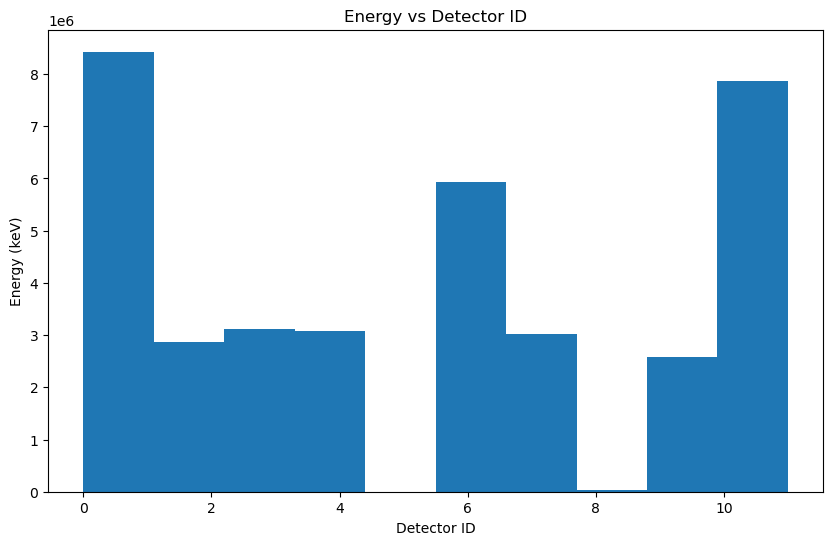

In [5]:
#energy vs detector id
'''try and see density (hist) of this
try and plot the same thing for each of the 12 detectors'''
plt.figure(figsize=(10, 6))
#plt.scatter(df['Detector ID'], df['Energy'], color='turquoise', marker='o', edgecolor = 'black', alpha=0.6)
plt.hist(sorted(df['Detector ID']))

plt.title('Energy vs Detector ID')
plt.xlabel('Detector ID')
plt.ylabel('Energy (keV)')
plt.show()

take out density = True
try counts per second or counts per second per KeV - guarding the height of the y axis with respect to the bin sizes
- separate bins will help give a sense of uniformity and get a sense of uniformity

code review: i implemented the changes from last week to scale the y axis for counts/s/kev units. other than that i did not change anything, and i think this is more meaningful because now the decline in the energy levels detected for each detector. also, this makes the patterns make more sense. i am curious about how these plots will look different once i start simulating things!

In [ ]:
#BEFORE 4/16 edits
from scipy.ndimage import gaussian_filter1d

xmin, xmax = 0, 1200
bin_number = 300
bins = np.linspace(xmin, xmax, bin_number + 1)
centers = (bins[:-1] + bins[1:]) / 2  

for detector in range(12):
    energies = df.loc[df['Detector ID'] == detector, 'Energy'].dropna().astype(float).values

    counts, _ = np.histogram(energies, bins=bins)
    smooth_density = gaussian_filter1d(counts, sigma=1.5)
    '''use plt.hist not np.histogram to get counts output
    for time counts use np.histogram output for time scaling
    '''
    plt.figure(figsize=(6, 4))
    plt.fill_between(centers, smooth_density, step='mid', alpha=0.6, color='turquoise')
    plt.plot(centers, smooth_density, color='navy', linewidth=1)
    plt.title(f'Energy density for Detector ID {detector}')
    plt.xlabel('Energy (keV)')
    plt.ylabel('Density')
    plt.xlim(xmin, xmax)
    plt.show()

In [ ]:
#AFTER 4/16 EDITS
from scipy.ndimage import gaussian_filter1d

xmin, xmax = 0, 1200
bin_number = 300
bins = np.linspace(xmin, xmax, bin_number + 1)
centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]
time = 86400

for detector in range(12):
    energies = df.loc[df['Detector ID'] == detector, 'Energy'].dropna().astype(float).values

    counts, _ = np.histogram(energies, bins=bins)
    counts_scaled = counts / time / bin_width 
    smooth_density = gaussian_filter1d(counts_scaled, sigma=1.5)

    plt.figure(figsize=(6, 4))
    plt.hist(energies, bins=bins, weights=np.ones(len(energies)) / time / bin_width, alpha=0.4, color='turquoise', edgecolor='none', label='Data')
    plt.fill_between(centers, smooth_density, step='mid', alpha=0.6, color='turquoise')
    plt.plot(centers, smooth_density, color='navy', linewidth=1)
    plt.title(f'Energy (keV) vs. counts/s/keV for Detector ID {detector}')
    plt.xlabel('Energy (keV)')
    plt.ylabel('Counts/s/keV')
    plt.xlim(xmin, xmax)
    plt.show()